## Nama: Faiz Iqbal I'tishom
## NIM: 164231059
## Kelas: SD-A1
## Tugas Klasifikasi II 

### Import Library

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score

### Subset Data

In [17]:
df = pd.read_csv('C:/Uner/Semester 4/Data Mining I/Week 6/carEvaluation.csv')

In [18]:
df.head()

,price,buying,maint,doors,persons,lug_boot,safety
0,4,4,2,2,small,1,unacc
1,4,4,2,2,small,2,unacc
2,4,4,2,2,small,3,unacc
3,4,4,2,2,2,1,unacc
4,4,4,2,2,2,2,unacc


#### Labeling

In [19]:
label_encoders = {}
for column in df.columns:
    le = LabelEncoder()
    df[column] = le.fit_transform(df[column])
    label_encoders[column] = le

### Spliting Data

In [20]:
X = df.drop(columns=['safety'])
y = df['safety']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

### Build Model

In [21]:
clf = DecisionTreeClassifier(criterion='gini', random_state=42)  
clf.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

### Evaluate Model

In [22]:
y_pred = clf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print(f'Accuracy: {accuracy:.2f}')
print(f'Precision: {precision:.2f}')
print(f'Recall: {recall:.2f}')
print(f'F1 Score: {f1:.2f}')
print('\nClassification Report:\n', classification_report(y_test, y_pred))

Accuracy: 0.97
Precision: 0.97
Recall: 0.97
F1 Score: 0.97

Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.92      0.94       118
           1       0.76      0.84      0.80        19
           2       0.99      1.00      0.99       358
           3       0.87      0.83      0.85        24

    accuracy                           0.97       519
   macro avg       0.89      0.90      0.90       519
weighted avg       0.97      0.97      0.97       519



### Display tree structure

In [23]:
tree_rules = export_text(clf, feature_names=list(X.columns))
print(tree_rules)

|--- lug_boot <= 0.50
|   |--- class: 2
|--- lug_boot >  0.50
|   |--- doors <= 0.50
|   |   |--- class: 2
|   |--- doors >  0.50
|   |   |--- price <= 1.50
|   |   |   |--- buying <= 0.50
|   |   |   |   |--- lug_boot <= 1.50
|   |   |   |   |   |--- persons <= 1.50
|   |   |   |   |   |   |--- maint <= 0.50
|   |   |   |   |   |   |   |--- persons <= 0.50
|   |   |   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |   |   |--- persons >  0.50
|   |   |   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |   |--- maint >  0.50
|   |   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |--- persons >  1.50
|   |   |   |   |   |   |--- maint <= 0.50
|   |   |   |   |   |   |   |--- doors <= 1.50
|   |   |   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |   |   |--- doors >  1.50
|   |   |   |   |   |   |   |   |--- class: 2
|   |   |   |   |   |   |--- maint >  0.50
|   |   |   |   |   |   |   |--- class: 0
|   |   |   |   |--- lug_boot >  1.50
|   |   |   |   |   |

### Plot decision tree

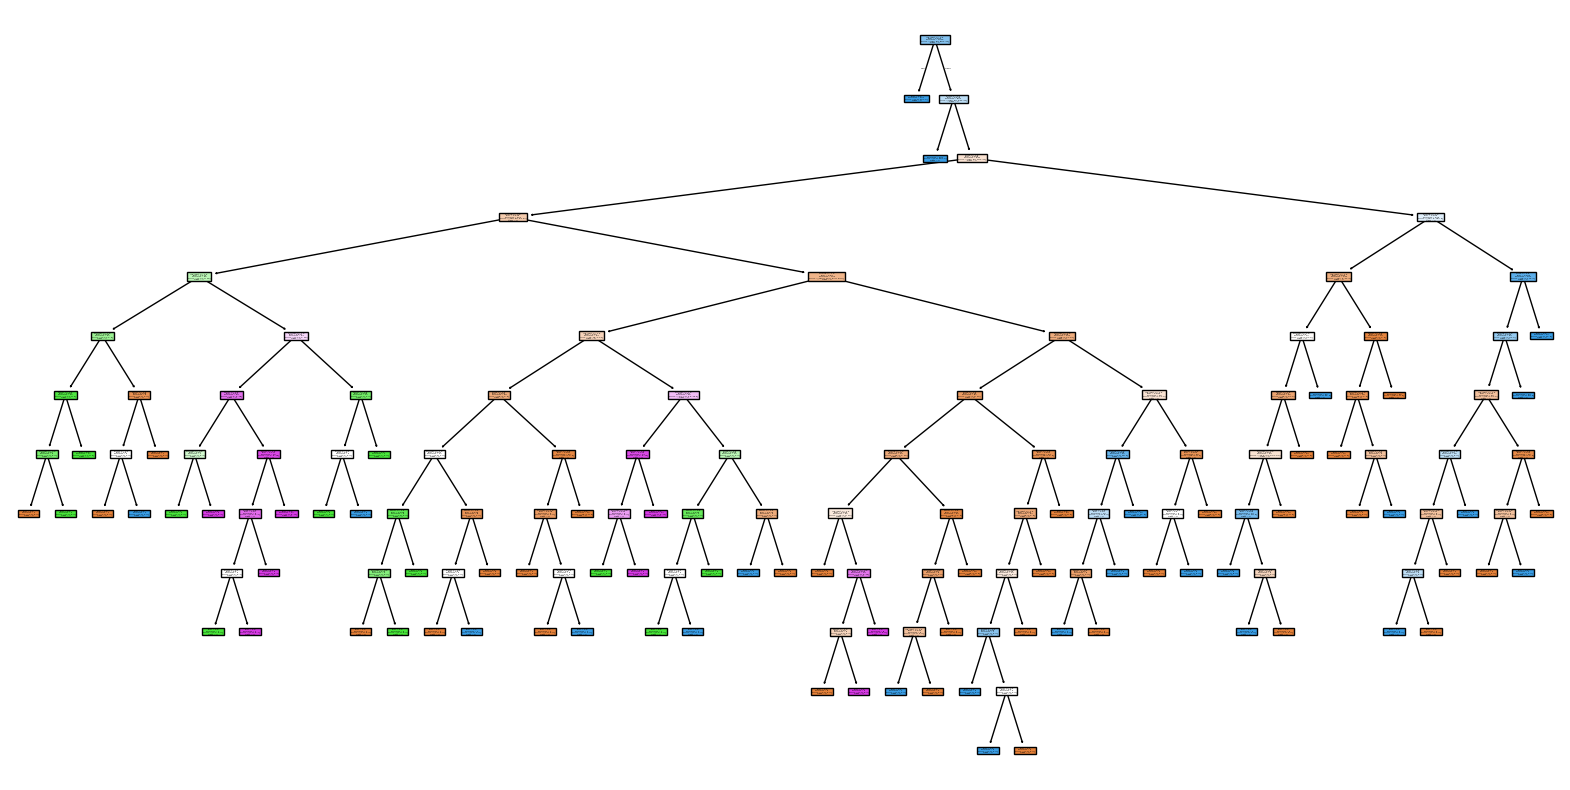

In [24]:
plt.figure(figsize=(20,10))
plot_tree(clf, feature_names=X.columns, class_names=[str(i) for i in set(y)], filled=True)
plt.show()

### Plot Confusion Matrix

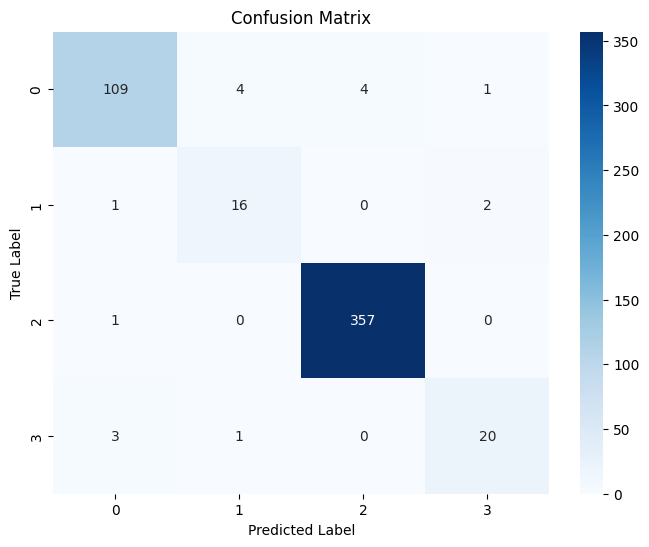

In [25]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y_train), yticklabels=np.unique(y_train))
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()